<center><u><H1>Statistical graphs with Matplotlib</H1></u></center>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

## <u>Scatter:</u>

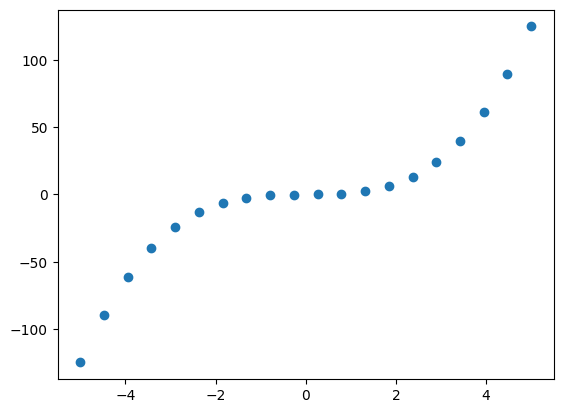

In [2]:
x = np.linspace(-5,5,20)
y = x**3
plt.scatter(x,y)

## <u>Scatter Plot Matrix:</u>

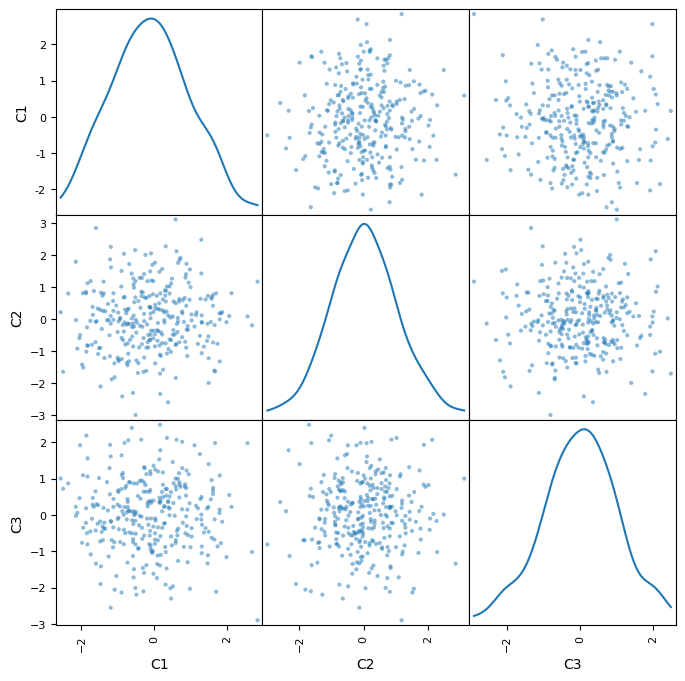

In [3]:
df = pd.DataFrame(np.random.randn(300,3),columns=['C1','C2','C3'])
mat = pd.plotting.scatter_matrix(df, alpha=0.5, figsize=(8,8),diagonal='kde')

## <u>Bar Chart:</u>

We have 5 groups of measures of test exams divided by gender and by group. Plot the bar chart.

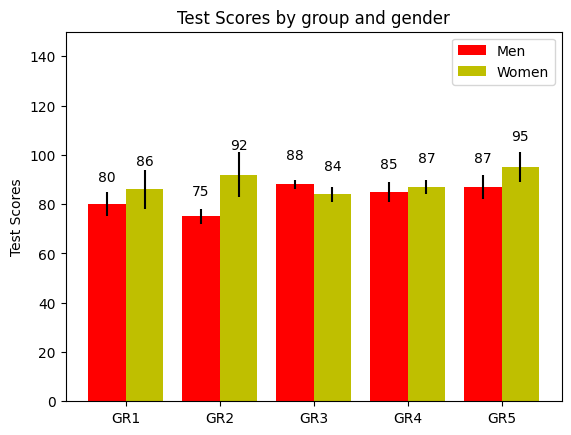

In [4]:
N = 5
men_means = (80, 75, 88, 85, 87)
men_std = (5, 3, 2, 4, 5)

ind = np.arange(N)  # the locations on the x axis for the groups
width = 0.4       # the width of the bars

fig, ax = plt.subplots()
r1 = ax.bar(ind, men_means, width, color='r', yerr=men_std)

women_means = (86, 92, 84, 87, 95)
women_std = (8, 9, 3, 3, 6)
r2 = ax.bar(ind + width, women_means, width, color='y', yerr=women_std)

ax.set_ylabel('Test Scores')
ax.set_ylim([0, 150])
ax.set_title('Test Scores by group and gender')
ax.set_xticks(ind + width / 2)
ax.set_xticklabels(('GR1', 'GR2', 'GR3', 'GR4', 'GR5'))

ax.legend((r1[0], r2[0]), ('Men', 'Women'),loc='best')

def _labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., 1.1*height,
                '%d' % int(height),
                ha='center', va='bottom')

_labels(r1)
_labels(r2)

plt.show()

## Horizontal Bar Chart

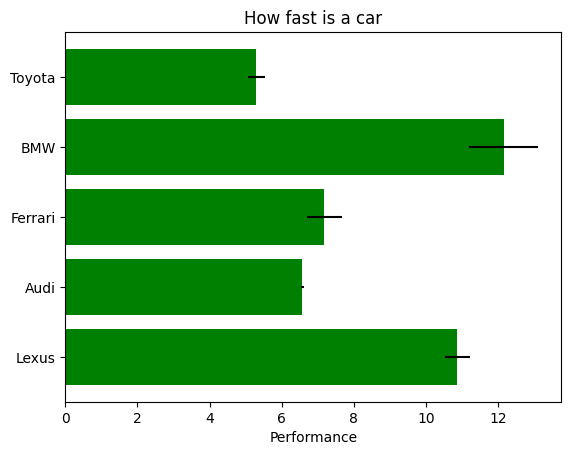

In [5]:
fig, ax = plt.subplots()

cars = ('Toyota', 'BMW', 'Ferrari', 'Audi', 'Lexus')
y_pos = np.arange(len(cars))
performance = 3 + 10 * np.random.rand(len(cars))
error = np.random.rand(len(cars))

ax.barh(y_pos, performance, xerr=error, align='center',
        color='green', ecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(cars)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Performance')
ax.set_title('How fast is a car')

plt.show()

## <u>Histogram:</u>

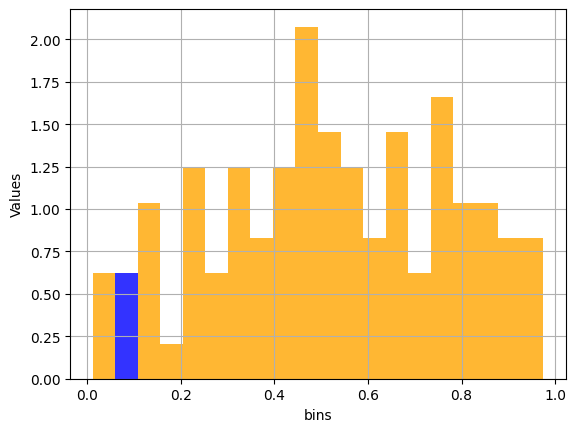

In [7]:
x = np.random.sample(100)
n, bins, patches = plt.hist(x, bins=20, facecolor='orange', alpha=0.80, density=True)
plt.setp(patches[1], 'facecolor', 'b')
plt.xlabel('bins')
plt.ylabel('Values')
plt.grid(True)

plt.show()

n: is the number of counts in each bin of the histogram

bins: is the left hand edge of each bin

patches: is the individual patches used to create the histogram, e.g a collection of rectangles

## <u>Pie Chart:</u>

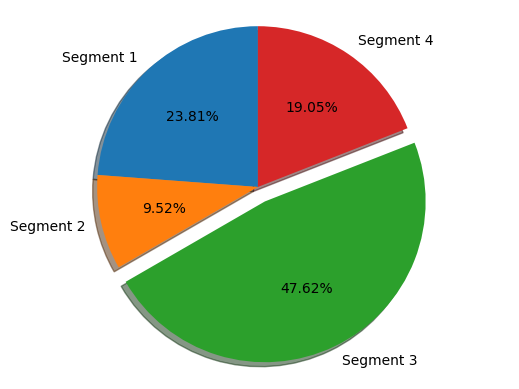

In [8]:
# Pie chart, where the slices are ordered and plotted counter-clockwise:
labels = 'Segment 1', 'Segment 2', 'Segment 3', 'Segment 4'
sizes = [25, 10, 50, 20]  # percentages, the sum of all of them must be 100%
explode = (0, 0, 0.1, 0)  # only "explode" the 3nd slice (i.e. 'Segment 3')

fig, ax = plt.subplots()
ax.pie(sizes, explode=explode, labels=labels, autopct='%1.2f%%',
        shadow=True, startangle=90)
#autopct: format of the numbers with decimals
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.show()

## <u>Box Plot:</u>

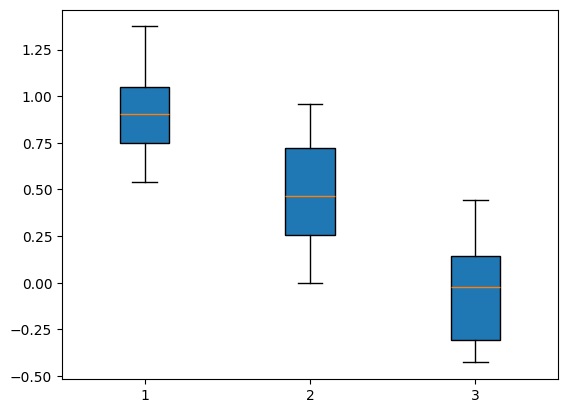

In [9]:
_high = np.random.rand(20) + 0.5
center = np.random.rand(20)
_low = np.random.rand(20) - 0.5

data = [_high,center,_low]
plt.boxplot(data,vert=True,patch_artist=True)
plt.show()

## <u>Bubble Charts:</u>

<Axes: xlabel='a', ylabel='b'>

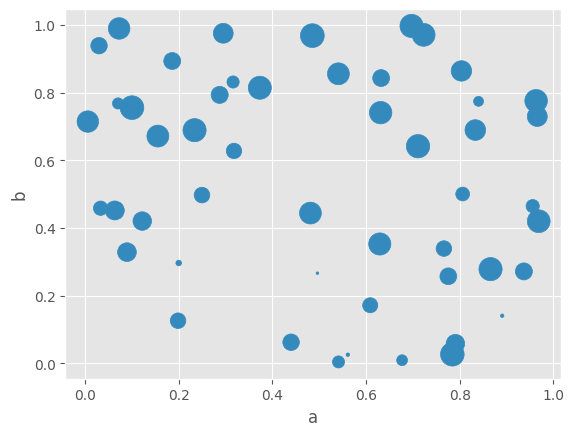

In [10]:
plt.style.use('ggplot')
df = pd.DataFrame(np.random.rand(50, 3), columns=['a','b','c'])
df.plot(kind='scatter',x='a',y='b',s=df['c']*300)
# s is the size of the bubble

## <u>Heat Maps:</u>

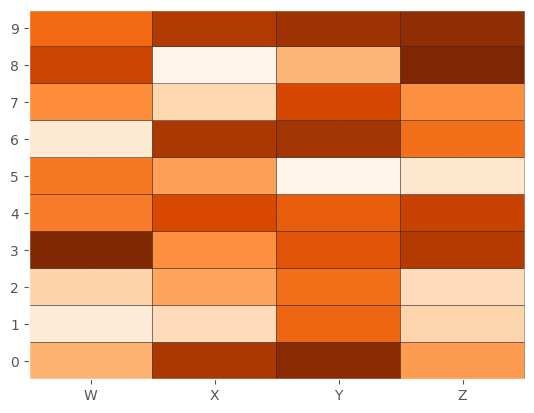

In [20]:
data = np.random.rand(10,4)
rows = list('0123456789')
cols = list('WXYZ')
plt.pcolor(data,cmap=plt.cm.Oranges_r,edgecolors='k')
plt.xticks(np.arange(0,4)+0.5,cols)
plt.yticks(np.arange(0,10)+0.5,rows)
plt.show()

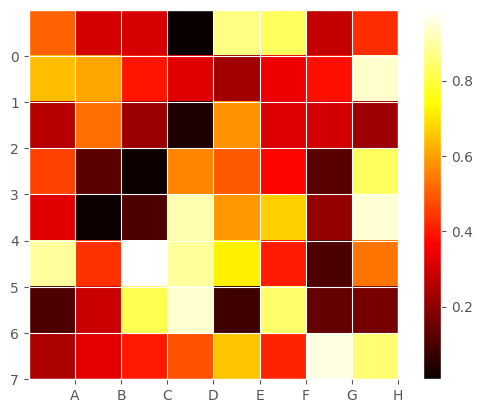

In [17]:
new_data = np.random.random((8, 8))
rows = list('01234567')
cols = list('ABCDEFGH')
plt.imshow(new_data, cmap='hot', interpolation='nearest')
plt.xticks(np.arange(0,8)+0.5,cols)
plt.yticks(np.arange(0,8)+0.5,rows)
plt.colorbar()
plt.show()

## VIOLIN Plot:

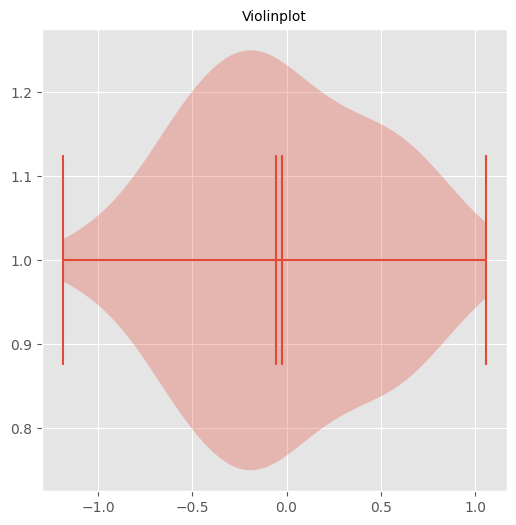

In [31]:
data = np.random.normal(0, 0.5, size=100)

fig, axes = plt.subplots(figsize=(6, 6))

axes.violinplot(data, widths=0.5,
                      showmeans=True, vert=False, showextrema=True, showmedians=True,
                     bw_method='silverman') #The method used to calculate the estimator bandwidth
axes.set_title('Violinplot', fontsize=10)
plt.show()

## ERROR BAR:

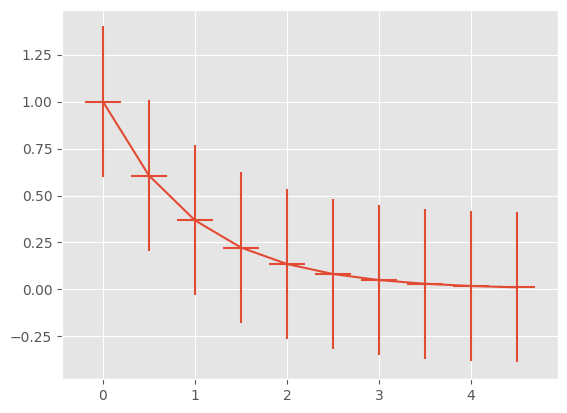

In [22]:
x = np.arange(0, 5, 0.5)
y = np.exp(-x)

fig, ax = plt.subplots()
ax.errorbar(x, y, xerr=0.2, yerr=0.4)
plt.show()

## <u>3D Plots:</u>

In [32]:
from mpl_toolkits.mplot3d.axes3d import Axes3D

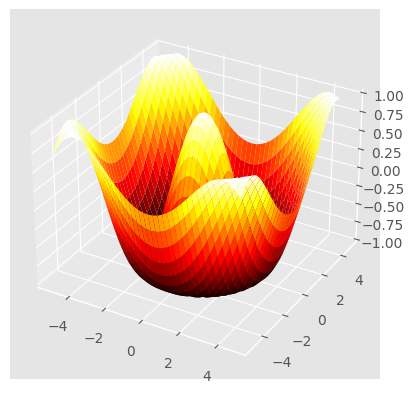

In [36]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = np.arange(-5, 5, 0.25)
y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(x, y)
F = np.sqrt(X**2 + Y**2)
Z = np.cos(F)

ax.plot_surface(X, Y, Z, cmap='hot', linewidth=0)

plt.show()

#### Color bar:

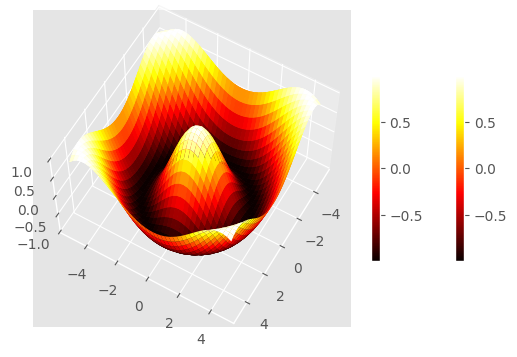

In [40]:
p = ax.plot_surface(X,Y,Z, rstride=1, cstride=1, cmap='hot',linewidth=0)
fig.colorbar(p, shrink=0.5)
fig
# The rstride and cstride parameters help in sizing the cell on the surface.

#### Setting the view angle:

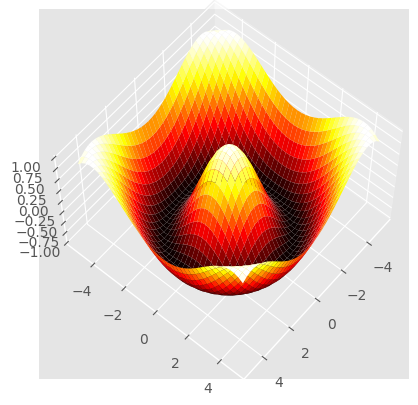

In [41]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=60., azim=40)
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='hot')

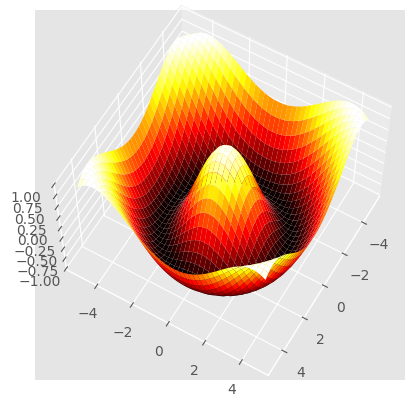

In [38]:
# setting the view at 60 degrees elevation and 30 degrees angle:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=60., azim=30)
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='hot')

## References:

https://matplotlib.org/2.0.1/examples/statistics/index.html

https://matplotlib.org/devdocs/api/_as_gen/matplotlib.axes.Axes.violinplot.html

https://matplotlib.org/mpl_toolkits/mplot3d/api.html